In [1]:
import os
from pathlib import Path

import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from huggingface_hub import snapshot_download

In [3]:
PROJECT_ROOT = Path.cwd().parent

print(PROJECT_ROOT)

d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization


In [4]:
# dataset_path = snapshot_download(
#     repo_id="star092304/Traffic-sign-detection-VietNam",
#     repo_type="dataset",
#     local_dir=PROJECT_ROOT / "dataset"
# )

# print("Dataset saved at:")
# print(dataset_path)

In [5]:
DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "traffic-sign-detection-vietnam"
    / "dataset"
)

print("Dataset root:")
print(DATASET_ROOT)

print("\nDataset exists:", DATASET_ROOT.exists())

Dataset root:
d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\traffic-sign-detection-vietnam\dataset

Dataset exists: True


In [6]:
TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"

VAL_IMAGES = DATASET_ROOT / "val" / "images"
VAL_LABELS = DATASET_ROOT / "val" / "labels"

TEST_IMAGES = DATASET_ROOT / "test" / "images"
TEST_LABELS = DATASET_ROOT / "test" / "labels"

paths = {
    "Train images": TRAIN_IMAGES,
    "Train labels": TRAIN_LABELS,
    "Val images": VAL_IMAGES,
    "Val labels": VAL_LABELS,
    "Test images": TEST_IMAGES,
    "Test labels": TEST_LABELS,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()}")

Train images: True
Train labels: True
Val images: True
Val labels: True
Test images: True
Test labels: True


In [7]:
def count_files(folder, extensions=None):
    files = [file for file in folder.iterdir() if file.is_file()]
    
    if extensions:
        files = [
            file for file in files
            if file.suffix.lower() in extensions
        ]
    
    return len(files)


dataset_summary = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "Images": [
        count_files(TRAIN_IMAGES, {".jpg", ".jpeg", ".png"}),
        count_files(VAL_IMAGES, {".jpg", ".jpeg", ".png"}),
        count_files(TEST_IMAGES, {".jpg", ".jpeg", ".png"})
    ],
    "Labels": [
        count_files(TRAIN_LABELS, {".txt"}),
        count_files(VAL_LABELS, {".txt"}),
        count_files(TEST_LABELS, {".txt"})
    ]
})

dataset_summary

,Split,Images,Labels
0,Train,8125,8125
1,Val,1016,1016
2,Test,1016,1016


In [8]:
def check_image_label_match(image_dir, label_dir):
    image_stems = {
        file.stem
        for file in image_dir.iterdir()
        if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
    }

    label_stems = {
        file.stem
        for file in label_dir.iterdir()
        if file.suffix.lower() == ".txt"
    }

    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems

    return missing_labels, missing_images

In [9]:
for split, image_dir, label_dir in [
    ("Train", TRAIN_IMAGES, TRAIN_LABELS),
    ("Val", VAL_IMAGES, VAL_LABELS),
    ("Test", TEST_IMAGES, TEST_LABELS)
]:
    
    missing_labels, missing_images = check_image_label_match(
        image_dir,
        label_dir
    )
    
    print(f"\n{split}")
    print("Missing labels:", len(missing_labels))
    print("Missing images:", len(missing_images))


Train
Missing labels: 0
Missing images: 0

Val
Missing labels: 0
Missing images: 0

Test
Missing labels: 0
Missing images: 0


In [10]:
CLASS_CSV = PROJECT_ROOT / "dataset" / "classid.csv"

class_df = pd.read_csv(CLASS_CSV)

print("Shape:", class_df.shape)
print("\nColumns:")
print(class_df.columns.tolist())

class_df.head(10)

Shape: (82, 4)

Columns:
['ID', 'classes-en', 'classes-vn', 'Count']


,ID,classes-en,classes-vn,Count
0,0,No Entry,Cấm đi ngược chiều,572
1,1,Turn Right Only,Đi về bên phải,524
2,2,Speed limit 40hm/h,Giới hạn tốc độ 40km/h,360
3,3,No Trucks and Bus,Cấm xe tải và buýt,127
4,4,No Trucks,Cấm xe tải,543
5,5,Low Clearance,Cảnh báo giới hạn chiều cao,161
6,6,No Cars,Cấm ô tô,279
7,7,Danger,Cảnh báo nguy hiểm,78
8,8,Slown Down,Giảm tốc độ,486
9,9,Double curve first to right,Nhiều chỗ ngoặc liên tiếp,323


In [11]:
class_df

,ID,classes-en,classes-vn,Count
0,0,No Entry,Cấm đi ngược chiều,572
1,1,Turn Right Only,Đi về bên phải,524
2,2,Speed limit 40hm/h,Giới hạn tốc độ 40km/h,360
3,3,No Trucks and Bus,Cấm xe tải và buýt,127
4,4,No Trucks,Cấm xe tải,543
...,...,...,...,...
77,77,Uneven road,đường không bằng phẳng,32
78,78,End of 50km/h speed limit,hết giới hạn tốc độ 50km/h,141
79,79,Residential area,Khu dân cư,164
80,80,sparsely populated area,Khu ít dân cư,117


In [12]:
sample_label = next(TRAIN_LABELS.glob("*.txt"))

print("Label file:")
print(sample_label)

print("\nContent:")
print(sample_label.read_text())

Label file:
d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\traffic-sign-detection-vietnam\dataset\train\labels\0002.txt

Content:
54 0.439411 0.529870 0.011260 0.015344
24 0.384875 0.522875 0.017500 0.016417


In [13]:
lines = sample_label.read_text().strip().splitlines()

print("Image:", sample_label.stem)
print("Number of objects:", len(lines))

for line in lines:
    print(line)

Image: 0002
Number of objects: 2
54 0.439411 0.529870 0.011260 0.015344
24 0.384875 0.522875 0.017500 0.016417


In [14]:
image_extensions = [".jpg", ".jpeg", ".png"]

sample_image = None

for ext in image_extensions:
    candidate = TRAIN_IMAGES / f"{sample_label.stem}{ext}"
    
    if candidate.exists():
        sample_image = candidate
        break

print("Label:", sample_label.name)
print("Image:", sample_image)

Label: 0002.txt
Image: d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\traffic-sign-detection-vietnam\dataset\train\images\0002.jpg


Image size: (640, 640)


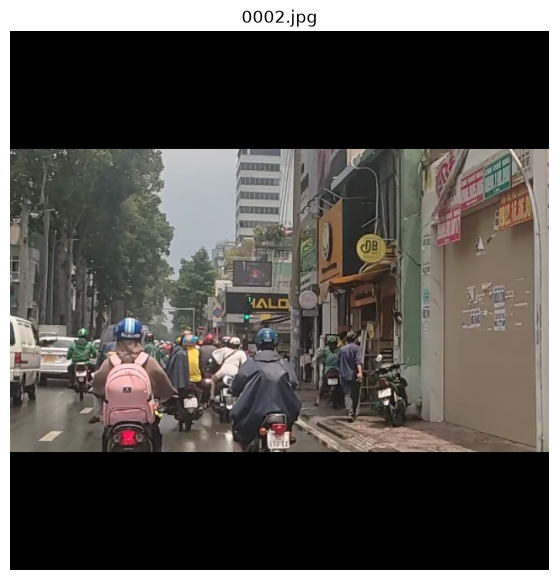

In [15]:
img = Image.open(sample_image)

print("Image size:", img.size)

plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis("off")
plt.title(sample_image.name)
plt.show()

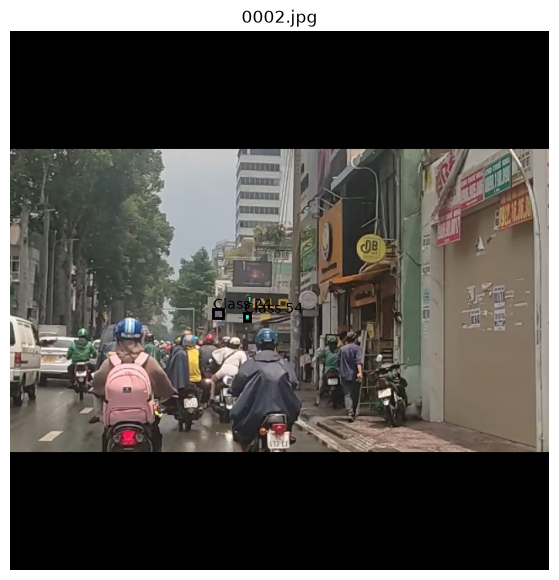

In [16]:
import matplotlib.patches as patches

img = Image.open(sample_image)
img_width, img_height = img.size

fig, ax = plt.subplots(figsize=(12, 7))

ax.imshow(img)

for line in lines:
    class_id, x_center, y_center, width, height = map(
        float,
        line.split()
    )

    # Chuyển từ normalized coordinates
    # sang pixel coordinates
    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    # Từ center -> góc trên bên trái
    x = x_center - width / 2
    y = y_center - height / 2

    rectangle = patches.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x,
        y,
        f"Class {int(class_id)}",
        fontsize=10
    )

ax.axis("off")
ax.set_title(sample_image.name)

plt.show()